In [2]:
!pip install pydotplus

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24635 sha256=6232beccf63c45d3b27d5690933c55be162038440653fedf30c58713e36df3f4
  Stored in directory: /home/kmea/.cache/pip/wheels/4a/c0/ed/a9eeeb08c3c53bb90d3822cf76557c8fdcbc349ee11a011169
Successfully built pydotplus


In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
from six import StringIO
from IPython.display import Image
import pydotplus

In [4]:
data = load_iris()

print("Classes to predict:", data.target_names)
print("Features:", data.feature_names)


Classes to predict: ['setosa' 'versicolor' 'virginica']
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
x = data.data
y = data.target

print(x.shape, y.shape)

(150, 4) (150,)


In [6]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, random_state=50, test_size=0.25
)

# Decision Tree using Gini
classifier = DecisionTreeClassifier()
classifier.fit(xtrain, ytrain)

y_pred = classifier.predict(xtest)

print(
    "Accuracy on train data using Gini:",
    accuracy_score(ytrain, classifier.predict(xtrain))
)

print(
    "Accuracy on test data using Gini:",
    accuracy_score(ytest, y_pred)
)


Accuracy on train data using Gini: 1.0
Accuracy on test data using Gini: 0.9473684210526315


In [7]:
classifier_entropy = DecisionTreeClassifier(criterion="entropy")
classifier_entropy.fit(xtrain, ytrain)

y_pred_entropy = classifier_entropy.predict(xtest)

print(
    "Accuracy on train data using Entropy:",
    accuracy_score(ytrain, classifier_entropy.predict(xtrain))
)

print(
    "Accuracy on test data using Entropy:",
    accuracy_score(ytest, y_pred_entropy)
)

Accuracy on train data using Entropy: 1.0
Accuracy on test data using Entropy: 0.9473684210526315


In [8]:
classifier_entropy1 = DecisionTreeClassifier(
    criterion="entropy",
    min_samples_split=50
)

classifier_entropy1.fit(xtrain, ytrain)

y_pred_entropy1 = classifier_entropy1.predict(xtest)

print(
    "Accuracy on train data using Entropy with min_samples_split=50:",
    accuracy_score(ytrain, classifier_entropy1.predict(xtrain))
)

print(
    "Accuracy on test data using Entropy with min_samples_split=50:",
    accuracy_score(ytest, y_pred_entropy1)
)

Accuracy on train data using Entropy with min_samples_split=50: 0.9642857142857143
Accuracy on test data using Entropy with min_samples_split=50: 0.9473684210526315


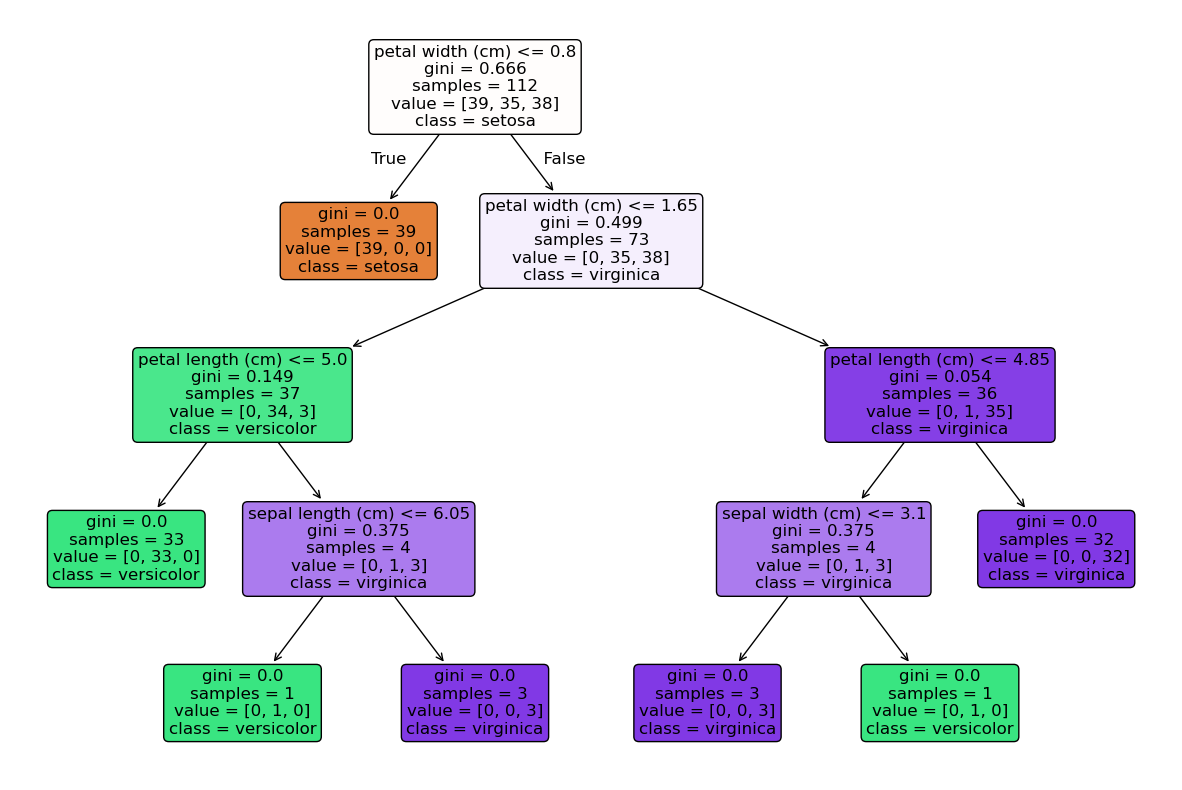

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))

plot_tree(
    classifier,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True
)

plt.show()